# Fetal Head Clinical AI — Phase 1: Pseudo-LDDM v2
**Author:** Tarun Sadarla  
**Depends on:** Phase 0 checkpoint at `/content/drive/MyDrive/fetal_head_clinical_ai/checkpoints/phase0/best_model.pth`

## What this notebook does
Converts static HC18 ultrasound frames into synthetic cine-loop sequences (16 frames each),
saved as paired `(frames, masks)` numpy arrays for Phase 2 training.

## Why v2 is different from the course v1
| Problem in v1 | Fix in v2 |
|---|---|
| Masks rigidly co-transform with frames | Per-frame cross-sectional variation — mask semi-axes perturbed independently |
| Sinusoidal motion — artificial periodicity | Ornstein-Uhlenbeck process — physically motivated correlated noise |
| Gaussian noise only | Rician speckle (correct US noise model) + depth attenuation |
| Reliability score always 1.0 | Genuine temporal variation forces real reliability estimation |

## Four generation stages (each independently verified)
- **Stage 1** — Rigid motion + cross-sectional mask variation
- **Stage 2** — Rician speckle + depth-dependent attenuation
- **Stage 3** — Ornstein-Uhlenbeck probe drift + fetal wiggle events
- **Stage 4** — Acoustic shadowing + TGC drift + probe jitter (full clinical fidelity)

## Output
```
Drive/fetal_head_clinical_ai/cine_dataset/
  train/  NNN_HC_clip_000.npz  ...   (frame array [16,H,W] + mask array [16,H,W])
  val/
  test/
  metadata.csv                       (stem, split, pixel_spacing, hc_gt_mm)
```

## 0. Setup

In [1]:
!pip install albumentations==1.4.0 kaggle opencv-python-headless --quiet
!pip install imageio[ffmpeg] --quiet   # for saving verification videos

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.6/123.6 kB 6.7 MB/s eta 0:00:00


In [2]:
import os, json, shutil, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from pathlib import Path
from tqdm import tqdm
import imageio

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR  = Path('/content/drive/MyDrive/fetal_head_clinical_ai')
CKPT_PATH    = PROJECT_DIR / 'checkpoints' / 'phase0' / 'best_model.pth'
CINE_DIR     = PROJECT_DIR / 'cine_dataset'
RESULTS_DIR  = PROJECT_DIR / 'results' / 'phase1'

for split in ['train', 'val', 'test']:
    (CINE_DIR / split).mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

assert CKPT_PATH.exists(), f'Phase 0 checkpoint not found at {CKPT_PATH}'
print('Phase 0 checkpoint found.')
print('Cine output dir:', CINE_DIR)

Mounted at /content/drive
Phase 0 checkpoint found.
Cine output dir: /content/drive/MyDrive/fetal_head_clinical_ai/cine_dataset


## 1. Re-download data + restore Phase 0 paths

In [4]:
from google.colab import files
import os
uploaded = files.upload()  # upload kaggle.json
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
shutil.move('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

DATA_DIR = Path('/content/hc18')
DATA_DIR.mkdir(exist_ok=True)
!kaggle datasets download -d tarunsadarla/hc18-apr -p /content/hc18 --unzip --quiet

TRAIN_DIR = DATA_DIR / 'archive (4)' / 'training_set' / 'training_set'
PIXEL_CSV = DATA_DIR / 'archive (4)' / 'training_set_pixel_size_and_HC.csv'
assert TRAIN_DIR.exists() and PIXEL_CSV.exists()

# Rebuild image_mask_pairs (same logic as Phase 0)
annotation_files   = sorted(TRAIN_DIR.glob('*_Annotation.png'))
image_mask_pairs   = []
for ann_path in annotation_files:
    img_path = TRAIN_DIR / ann_path.name.replace('_Annotation.png', '.png')
    if img_path.exists():
        image_mask_pairs.append((img_path, ann_path))

print(f'Image/mask pairs: {len(image_mask_pairs)}')

# Load Phase 0 split so train/val/test are identical
split_path = PROJECT_DIR / 'results' / 'phase0' / 'data_split.json'
with open(split_path) as f:
    split_record = json.load(f)

# Map stem → (img_path, mask_path)
stem_to_pair = {}
for img_path, mask_path in image_mask_pairs:
    stem = img_path.stem.replace('_HC','').replace('_2HC','').replace('_3HC','').replace('_4HC','')
    stem_to_pair[stem] = (img_path, mask_path)

train_pairs = [stem_to_pair[s] for s in split_record['train'] if s in stem_to_pair]
val_pairs   = [stem_to_pair[s] for s in split_record['val']   if s in stem_to_pair]
test_pairs  = [stem_to_pair[s] for s in split_record['test']  if s in stem_to_pair]

print(f'Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}')

# Load pixel spacing metadata
df_meta = pd.read_csv(PIXEL_CSV)
df_meta.columns = [c.strip().lower().replace(' ','_').replace('(','').replace(')','') for c in df_meta.columns]
PIXEL_COL = [c for c in df_meta.columns if 'pixel' in c][0]
HC_COL    = [c for c in df_meta.columns if 'head' in c or 'hc' in c.lower()][-1]
FILE_COL  = [c for c in df_meta.columns if 'file' in c][0]
stem_to_meta = {
    str(row[FILE_COL]).replace('_HC.png','').replace('.png',''): {
        'pixel_spacing': float(row[PIXEL_COL]),
        'hc_gt_mm': float(row[HC_COL])
    }
    for _, row in df_meta.iterrows()
}
print(f'Pixel spacing metadata loaded for {len(stem_to_meta)} images')

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/tarunsadarla/hc18-apr
License(s): apache-2.0

Image/mask pairs: 999
Train: 564 | Val: 121 | Test: 121
Pixel spacing metadata loaded for 999 images


## 2. Helper: load and fill mask
Reused from Phase 0 — flood-fill hollow ellipse annotation into solid binary mask.

In [5]:
INPUT_H, INPUT_W = 256, 384
N_FRAMES = 16   # frames per cine clip

def load_image_mask(img_path, mask_path, target_h=INPUT_H, target_w=INPUT_W):
    """
    Load and preprocess one image/mask pair.
    Returns:
        img:  [H, W] uint8 grayscale, resized
        mask: [H, W] uint8 binary {0,1}, filled solid ellipse, resized
    """
    img  = cv2.imread(str(img_path),  cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    # Resize to training dimensions
    img  = cv2.resize(img,  (target_w, target_h), interpolation=cv2.INTER_LINEAR)
    mask = cv2.resize(mask, (target_w, target_h), interpolation=cv2.INTER_NEAREST)

    # Binarise
    _, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    # Flood-fill
    h, w = mask_bin.shape
    fm = np.zeros((h+2, w+2), dtype=np.uint8)
    filled = mask_bin.copy()
    cv2.floodFill(filled, fm, (0,0), 255)
    solid = cv2.bitwise_or(mask_bin, cv2.bitwise_not(filled))
    solid = (solid > 127).astype(np.uint8)

    return img, solid


def get_ellipse_params(mask):
    """
    Fit an ellipse to the filled mask and return its parameters.
    Returns dict with cx, cy (centre), a, b (semi-axes), angle (degrees)
    or None if no contour found.
    """
    contours, _ = cv2.findContours(
        (mask * 255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    if not contours:
        return None
    largest = max(contours, key=cv2.contourArea)
    if len(largest) < 5:
        return None
    (cx, cy), (ma, mi), angle = cv2.fitEllipse(largest)
    return {'cx': cx, 'cy': cy, 'a': ma/2, 'b': mi/2, 'angle': angle}


# Quick test
test_img, test_mask = load_image_mask(*image_mask_pairs[0])
ep = get_ellipse_params(test_mask)
print(f'Image shape: {test_img.shape}, Mask unique: {np.unique(test_mask)}')
print(f'Ellipse params: cx={ep["cx"]:.1f}, cy={ep["cy"]:.1f}, a={ep["a"]:.1f}, b={ep["b"]:.1f}, angle={ep["angle"]:.1f}')

Image shape: (256, 384), Mask unique: [0 1]
Ellipse params: cx=196.7, cy=179.3, a=44.5, b=52.7, angle=25.5


## 3. Ornstein-Uhlenbeck motion process

**Why OU instead of sinusoids (v1)?**  
Sinusoidal motion creates perfectly periodic sequences — the model learns the pattern
instead of learning to segment. The Ornstein-Uhlenbeck process generates correlated
random motion that is:
- Mean-reverting (probe naturally returns toward the standard plane)
- Non-periodic (no repeating pattern)
- Smooth (continuous, not jumpy)

Physically: this models a sonographer holding the probe with slight hand tremor
and drift, always trying to maintain the standard transcerebellar plane.

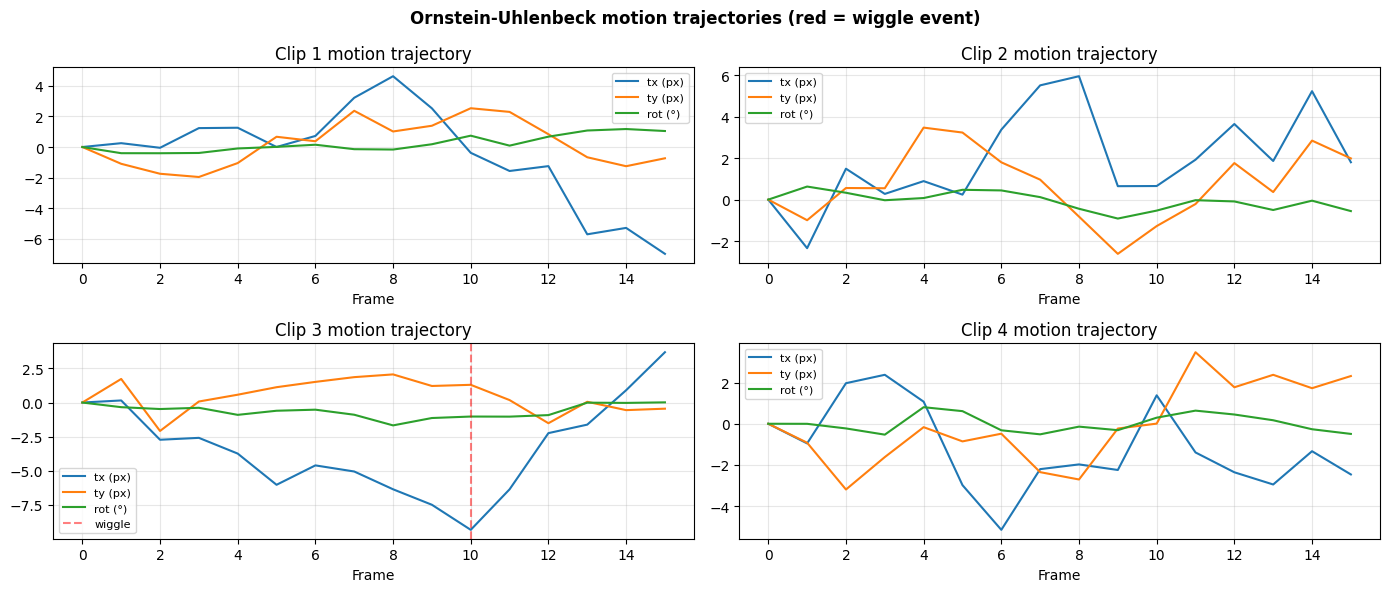

OU process verified — non-periodic, mean-reverting motion.


In [6]:
def ornstein_uhlenbeck(n_steps, mu=0.0, theta=0.3, sigma=1.0, dt=1.0, x0=0.0, rng=None):
    """
    Generate an Ornstein-Uhlenbeck trajectory.

    OU SDE: dx = theta*(mu - x)*dt + sigma*sqrt(dt)*dW

    Parameters:
        mu:    long-term mean (0 = probe returns to standard plane)
        theta: mean-reversion speed (higher = snaps back faster)
        sigma: noise magnitude
        dt:    time step
        x0:   initial position

    Returns: [n_steps] float array
    """
    if rng is None:
        rng = np.random.default_rng()
    x = np.zeros(n_steps)
    x[0] = x0
    for t in range(1, n_steps):
        dW = rng.normal(0, np.sqrt(dt))
        x[t] = x[t-1] + theta * (mu - x[t-1]) * dt + sigma * dW
    return x


def generate_motion_trajectory(n_frames, rng):
    """
    Generate per-frame motion parameters for a cine clip.

    Returns dict of arrays, each length n_frames:
        tx: x translation (pixels)
        ty: y translation (pixels)
        rot: rotation (degrees)
        scale: uniform scale factor
        wiggle: boolean flags for fetal wiggle frames
    """
    # Slow drift: low theta (slow reversion), low sigma (gentle movement)
    tx  = ornstein_uhlenbeck(n_frames, theta=0.15, sigma=2.0,  rng=rng)  # ±~5px
    ty  = ornstein_uhlenbeck(n_frames, theta=0.15, sigma=1.5,  rng=rng)  # ±~3px
    rot = ornstein_uhlenbeck(n_frames, theta=0.2,  sigma=0.4,  rng=rng)  # ±~1°

    # Scale variation: subtle (simulates slight depth change)
    scale_noise = ornstein_uhlenbeck(n_frames, theta=0.3, sigma=0.005, rng=rng)
    scale = 1.0 + scale_noise

    # Fetal wiggle events: sudden displacement in 1-2 random frames
    # Probability 30% that this clip contains a wiggle at all
    wiggle = np.zeros(n_frames, dtype=bool)
    if rng.random() < 0.3:
        wiggle_frame = rng.integers(2, n_frames - 2)
        wiggle[wiggle_frame] = True
        # Wiggle = sudden offset that partially recovers
        wiggle_tx = rng.normal(0, 8)  # larger sudden displacement
        wiggle_ty = rng.normal(0, 6)
        tx[wiggle_frame:]   += wiggle_tx * np.exp(-0.5 * np.arange(n_frames - wiggle_frame))
        ty[wiggle_frame:]   += wiggle_ty * np.exp(-0.5 * np.arange(n_frames - wiggle_frame))

    return {'tx': tx, 'ty': ty, 'rot': rot, 'scale': scale, 'wiggle': wiggle}


# Visualise a few motion trajectories
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
rng_vis = np.random.default_rng(0)
for i in range(4):
    traj = generate_motion_trajectory(N_FRAMES, rng_vis)
    ax = axes[i//2, i%2]
    ax.plot(traj['tx'],  label='tx (px)')
    ax.plot(traj['ty'],  label='ty (px)')
    ax.plot(traj['rot'], label='rot (°)')
    for f in np.where(traj['wiggle'])[0]:
        ax.axvline(f, color='red', linestyle='--', alpha=0.5, label='wiggle')
    ax.set_title(f'Clip {i+1} motion trajectory')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_xlabel('Frame')
plt.suptitle('Ornstein-Uhlenbeck motion trajectories (red = wiggle event)', fontweight='bold')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'motion_trajectories.png'), dpi=120, bbox_inches='tight')
plt.show()
print('OU process verified — non-periodic, mean-reverting motion.')

## 4. Cross-sectional mask variation

**The key v2 fix.** In v1, the ground truth mask was rigidly co-transformed with
the image — so the model saw perfect mask tracking and learned nothing about
temporal uncertainty. The reliability score was always 1.0 because there was
never any genuine variation to measure.

In reality, probe drift changes the imaging plane — you see a slightly different
cross-section of the skull in each frame. This is modelled as small independent
perturbations to the ellipse semi-axes (a, b) per frame, in addition to the
rigid transform. The model now must handle masks that genuinely vary across
a clip, which forces real temporal reasoning.

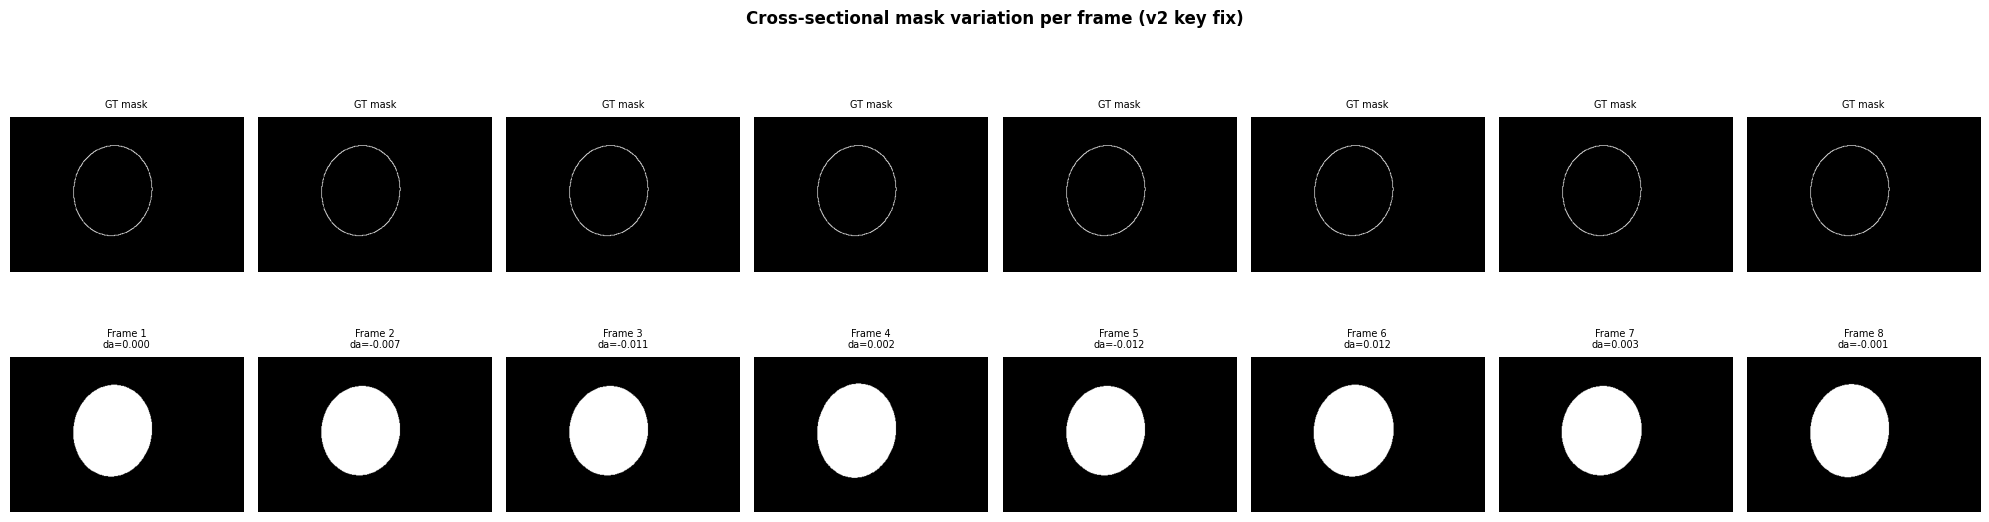

In [7]:
def apply_rigid_transform(img, tx, ty, rot_deg, scale, border_value=0):
    """
    Apply affine transform (translation + rotation + scale) to an image.
    Centre of rotation is the image centre.
    """
    h, w = img.shape[:2]
    cx, cy = w / 2, h / 2
    M = cv2.getRotationMatrix2D((cx, cy), rot_deg, scale)
    M[0, 2] += tx
    M[1, 2] += ty
    return cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR,
                          borderMode=cv2.BORDER_CONSTANT, borderValue=border_value)


def perturb_mask_cross_section(mask, ellipse_params, da_frac, db_frac, rng):
    """
    Generate a slightly different cross-section by perturbing ellipse semi-axes.

    da_frac, db_frac: fractional change to semi-axes a and b (e.g. 0.03 = ±3%)
    This simulates seeing a slightly off-plane cross-section of the skull.

    Returns: new binary mask [H, W]
    """
    ep = ellipse_params
    h, w = mask.shape

    # Perturb semi-axes independently
    new_a = max(ep['a'] * (1 + da_frac), ep['a'] * 0.85)  # clamp: don't shrink > 15%
    new_b = max(ep['b'] * (1 + db_frac), ep['b'] * 0.85)

    # Draw new filled ellipse
    new_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.ellipse(
        new_mask,
        center=(int(round(ep['cx'])), int(round(ep['cy']))),
        axes=(int(round(new_a)), int(round(new_b))),
        angle=ep['angle'],
        startAngle=0, endAngle=360,
        color=1, thickness=-1  # filled
    )
    return new_mask


# Visualise cross-sectional variation on one sample
img0, mask0 = load_image_mask(*image_mask_pairs[10])
ep0 = get_ellipse_params(mask0)
rng_vis = np.random.default_rng(7)

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for f in range(8):
    da = rng_vis.normal(0, 0.025)  # ±2.5% semi-axis variation per frame
    db = rng_vis.normal(0, 0.025)
    m_var = perturb_mask_cross_section(mask0, ep0, da, db, rng_vis)
    axes[0, f].imshow(mask0,  cmap='gray'); axes[0, f].set_title(f'GT mask',    fontsize=7); axes[0, f].axis('off')
    axes[1, f].imshow(m_var,  cmap='gray'); axes[1, f].set_title(f'Frame {f+1}\nda={da:.3f}', fontsize=7); axes[1, f].axis('off')
plt.suptitle('Cross-sectional mask variation per frame (v2 key fix)', fontweight='bold')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'cross_section_variation.png'), dpi=120, bbox_inches='tight')
plt.show()

## 5. Ultrasound physics simulation

### Rician speckle noise
Ultrasound speckle is NOT Gaussian. It follows a Rician distribution, which arises
from coherent backscatter of ultrasound waves. Rician noise = magnitude of two
independent Gaussian channels → heavier tails than Gaussian, spatially correlated.

### Depth-dependent attenuation
Ultrasound energy attenuates with depth (~0.5 dB/cm/MHz). The image gets darker
at the bottom. This is what TGC (time-gain compensation) corrects for, but never
perfectly — residual attenuation gradient is always present.

### Acoustic shadowing
Bone (skull) reflects nearly all ultrasound energy → dark shadow below it.
Modelled as a region of suppressed intensity beneath the skull boundary.

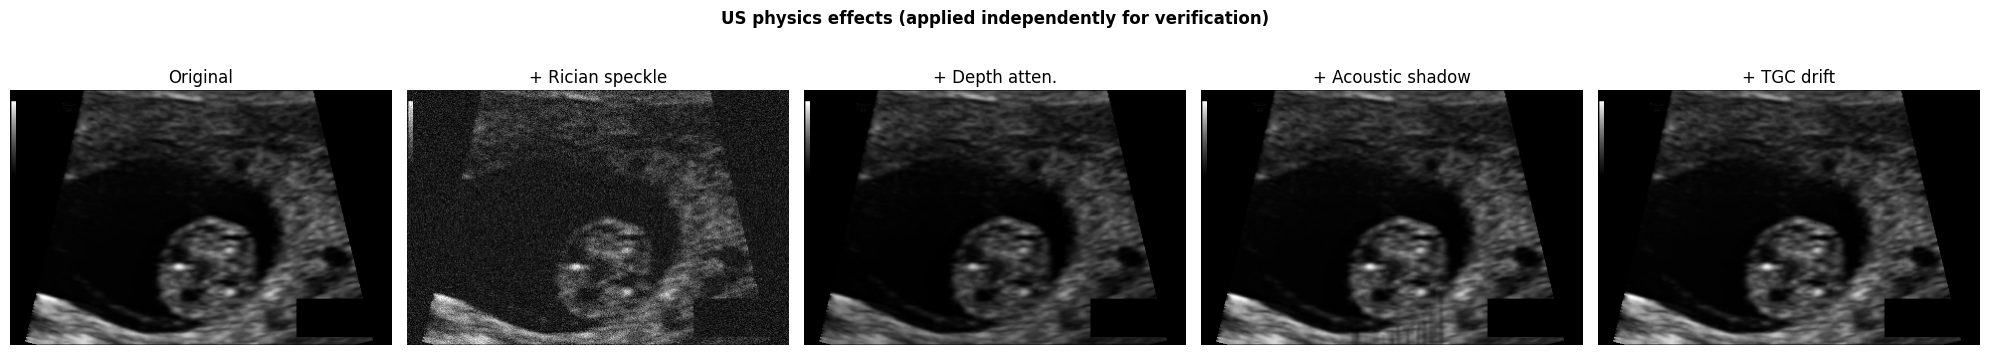

In [8]:
def add_rician_speckle(img_float, noise_std=0.08, rng=None):
    """
    Add Rician speckle noise to a [0,1] float image.

    Rician noise: magnitude of complex Gaussian noise added to signal.
    Result = sqrt((img + n1)^2 + n2^2) where n1,n2 ~ N(0, sigma)

    This correctly models coherent ultrasound backscatter.
    """
    if rng is None:
        rng = np.random.default_rng()
    n1 = rng.normal(0, noise_std, img_float.shape).astype(np.float32)
    n2 = rng.normal(0, noise_std, img_float.shape).astype(np.float32)
    noisy = np.sqrt((img_float + n1)**2 + n2**2)
    return np.clip(noisy, 0, 1)


def add_depth_attenuation(img_float, attenuation_coeff=0.4):
    """
    Apply depth-dependent intensity attenuation.
    Top of image (near field) = no attenuation.
    Bottom (far field) = multiplied by exp(-coeff).

    attenuation_coeff: 0.4 produces ~33% intensity reduction at bottom.
    """
    h, w = img_float.shape
    depth = np.linspace(0, attenuation_coeff, h, dtype=np.float32)
    attenuation = np.exp(-depth)[:, np.newaxis]  # [H, 1] broadcast over width
    return img_float * attenuation


def add_acoustic_shadow(img_float, mask, shadow_strength=0.5, rng=None):
    """
    Add acoustic shadow below the skull boundary.

    Finds the bottom edge of the skull mask per column,
    then suppresses intensity below it by shadow_strength.
    shadow_strength=0.5 means 50% intensity reduction in shadow zone.
    """
    if rng is None:
        rng = np.random.default_rng()
    h, w = img_float.shape
    shadow_map = np.ones((h, w), dtype=np.float32)

    # Only apply to ~40% of columns (realistic — shadow appears where bone is thickest)
    shadow_cols = rng.choice(w, size=int(w * 0.4), replace=False)

    for col in shadow_cols:
        skull_rows = np.where(mask[:, col] > 0)[0]
        if len(skull_rows) == 0:
            continue
        bottom_of_skull = skull_rows.max()
        # Shadow extends from bottom of skull to image bottom
        shadow_depth = min(bottom_of_skull + rng.integers(5, 20), h)
        shadow_map[shadow_depth:, col] *= (1 - shadow_strength)

    # Smooth the shadow boundary to avoid hard edges
    shadow_map = cv2.GaussianBlur(shadow_map, (7, 1), 0)
    return img_float * shadow_map


def add_tgc_drift(img_float, max_drift=0.08, rng=None):
    """
    Simulate TGC (time-gain compensation) drift.
    TGC is the machine's attempt to correct depth attenuation —
    but it drifts slightly between frames, causing inter-frame intensity variation.
    """
    if rng is None:
        rng = np.random.default_rng()
    h = img_float.shape[0]
    drift_amount = rng.uniform(-max_drift, max_drift)
    tgc = np.linspace(1.0, 1.0 + drift_amount, h, dtype=np.float32)[:, np.newaxis]
    return np.clip(img_float * tgc, 0, 1)


# Visualise each physics effect independently
img_f = test_img.astype(np.float32) / 255.0
rng_vis = np.random.default_rng(42)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes[0].imshow(img_f,                                               cmap='gray'); axes[0].set_title('Original');           axes[0].axis('off')
axes[1].imshow(add_rician_speckle(img_f, rng=rng_vis),             cmap='gray'); axes[1].set_title('+ Rician speckle');   axes[1].axis('off')
axes[2].imshow(add_depth_attenuation(img_f),                        cmap='gray'); axes[2].set_title('+ Depth atten.');     axes[2].axis('off')
axes[3].imshow(add_acoustic_shadow(img_f, test_mask, rng=rng_vis), cmap='gray'); axes[3].set_title('+ Acoustic shadow');  axes[3].axis('off')
axes[4].imshow(add_tgc_drift(img_f, rng=rng_vis),                  cmap='gray'); axes[4].set_title('+ TGC drift');        axes[4].axis('off')
plt.suptitle('US physics effects (applied independently for verification)', fontweight='bold')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'physics_effects.png'), dpi=120, bbox_inches='tight')
plt.show()

## 6. Full clip generator — combining all stages

In [9]:
def generate_cine_clip(img, mask, n_frames=N_FRAMES, rng=None, stage=4):
    """
    Generate a synthetic cine-loop clip from a static image/mask pair.

    Parameters:
        img:      [H, W] uint8 grayscale ultrasound
        mask:     [H, W] uint8 binary filled mask
        n_frames: number of frames in the clip
        rng:      numpy random generator (for reproducibility)
        stage:    1-4, controls which effects are applied
                  1 = rigid motion only
                  2 = + Rician speckle + depth attenuation
                  3 = + OU motion + wiggle events
                  4 = + acoustic shadow + TGC drift (full clinical fidelity)

    Returns:
        frames: [n_frames, H, W] float32 array, values in [0, 1]
        masks:  [n_frames, H, W] uint8 array, binary {0, 1}
    """
    if rng is None:
        rng = np.random.default_rng()

    H, W = img.shape
    img_float = img.astype(np.float32) / 255.0

    # Get ellipse parameters for cross-sectional variation
    ep = get_ellipse_params(mask)

    # Generate motion trajectory
    if stage >= 3:
        traj = generate_motion_trajectory(n_frames, rng)
    else:
        # Stage 1-2: simple sinusoidal motion (kept for ablation comparison)
        t = np.linspace(0, 2*np.pi, n_frames)
        traj = {
            'tx':     np.sin(t) * 4,
            'ty':     np.cos(t) * 2,
            'rot':    np.sin(t * 0.5) * 1.5,
            'scale':  1.0 + np.sin(t * 0.3) * 0.02,
            'wiggle': np.zeros(n_frames, dtype=bool)
        }

    frames = []
    masks  = []

    for f in range(n_frames):
        # --- Image transform ---
        frame = apply_rigid_transform(
            img_float, traj['tx'][f], traj['ty'][f],
            traj['rot'][f], traj['scale'][f]
        )

        # --- Physics (stage 2+) ---
        if stage >= 2:
            noise_std = rng.uniform(0.05, 0.12)  # variable speckle per frame
            frame = add_rician_speckle(frame, noise_std=noise_std, rng=rng)
            frame = add_depth_attenuation(frame, attenuation_coeff=rng.uniform(0.2, 0.5))

        # --- Acoustic shadow + TGC (stage 4) ---
        if stage >= 4:
            # Transform the mask for shadow calculation (same transform as image)
            mask_transformed = apply_rigid_transform(
                mask.astype(np.float32), traj['tx'][f], traj['ty'][f],
                traj['rot'][f], traj['scale'][f]
            )
            mask_t_bin = (mask_transformed > 0.5).astype(np.uint8)
            frame = add_acoustic_shadow(frame, mask_t_bin, rng=rng)
            frame = add_tgc_drift(frame, rng=rng)

        frames.append(np.clip(frame, 0, 1).astype(np.float32))

        # --- Mask: cross-sectional variation + rigid transform ---
        if ep is not None:
            da = rng.normal(0, 0.025)  # ±2.5% semi-axis variation
            db = rng.normal(0, 0.025)
            mask_varied = perturb_mask_cross_section(mask, ep, da, db, rng)
        else:
            mask_varied = mask.copy()

        # Apply same rigid transform to the varied mask
        mask_transformed = apply_rigid_transform(
            mask_varied.astype(np.float32),
            traj['tx'][f], traj['ty'][f],
            traj['rot'][f], traj['scale'][f],
            border_value=0
        )
        masks.append((mask_transformed > 0.5).astype(np.uint8))

    return np.stack(frames, axis=0), np.stack(masks, axis=0)


# Test: generate one clip and verify shapes
rng_test = np.random.default_rng(0)
test_frames, test_masks = generate_cine_clip(test_img, test_mask, rng=rng_test, stage=4)
print(f'Frames shape: {test_frames.shape}  dtype: {test_frames.dtype}  range: [{test_frames.min():.3f}, {test_frames.max():.3f}]')
print(f'Masks  shape: {test_masks.shape}   dtype: {test_masks.dtype}   unique: {np.unique(test_masks)}')

Frames shape: (16, 256, 384)  dtype: float32  range: [0.000, 0.993]
Masks  shape: (16, 256, 384)   dtype: uint8   unique: [0 1]


## 7. Stage verification — visualise each stage

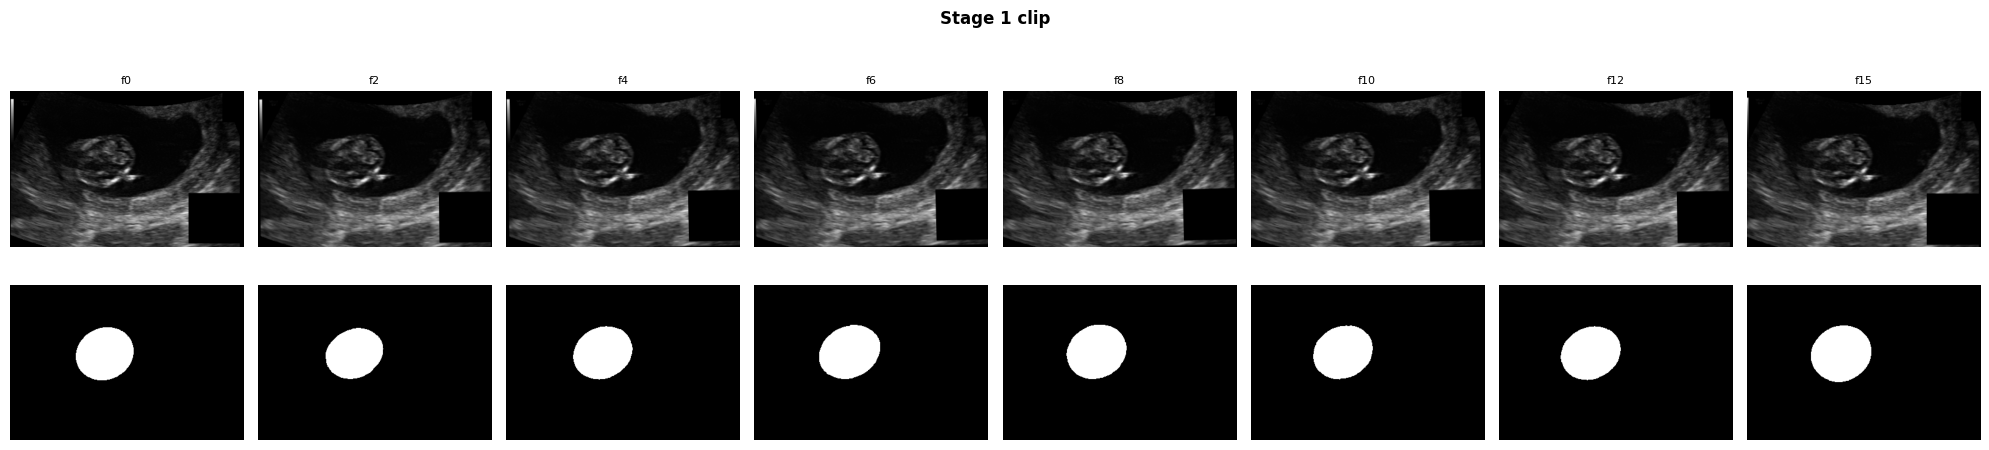

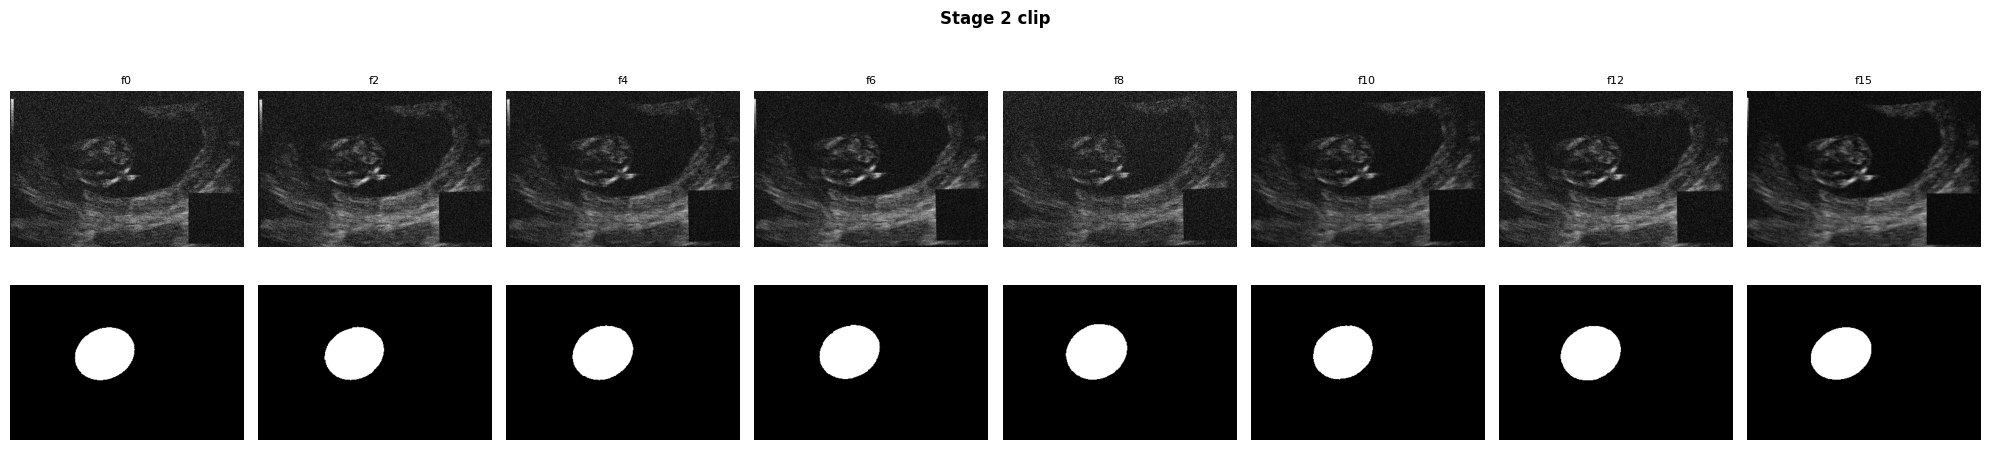

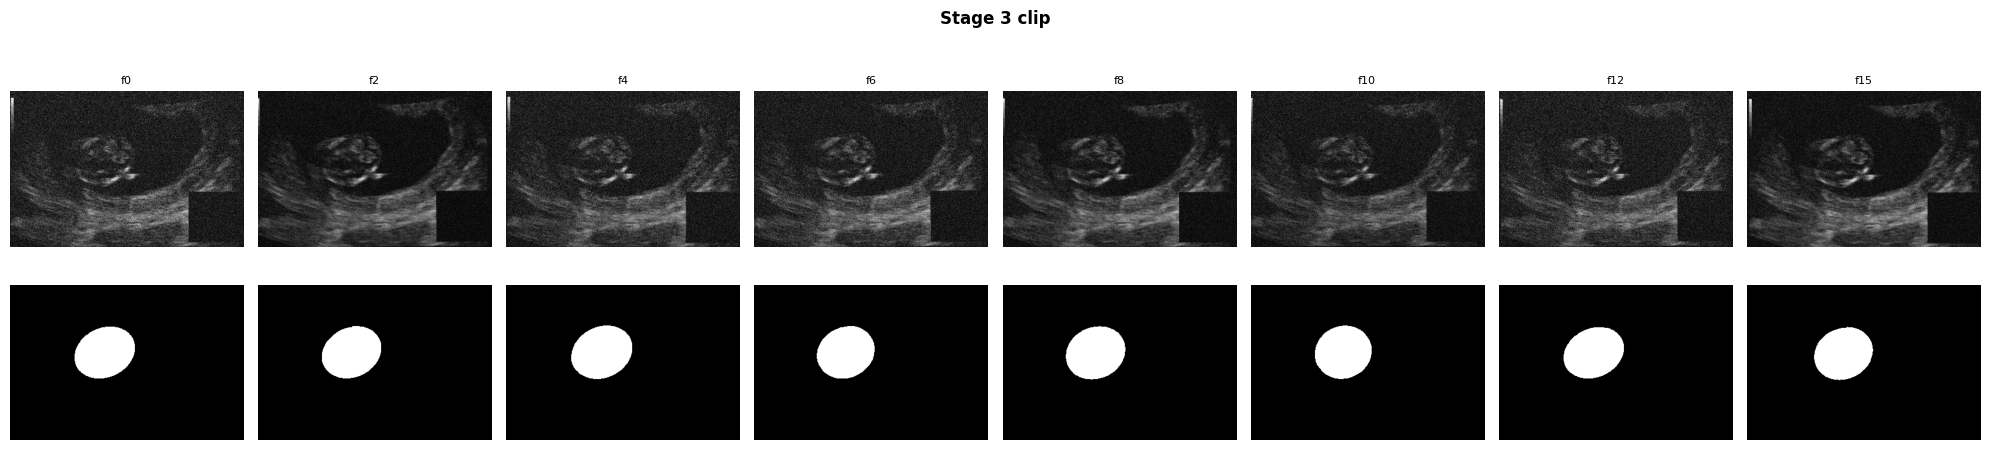

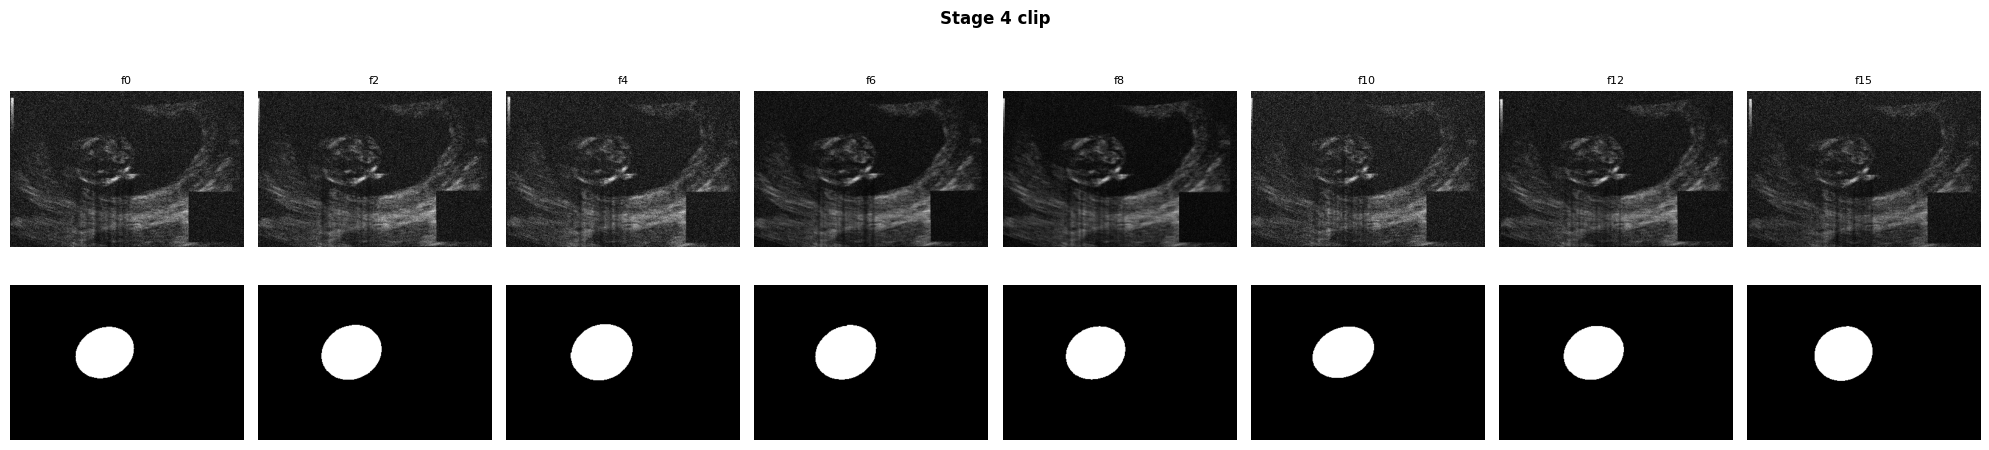

In [10]:
def visualise_clip(frames, masks, title, save_path=None, n_show=8):
    """Show n_show frames from a clip with their masks."""
    indices = np.linspace(0, len(frames)-1, n_show, dtype=int)
    fig, axes = plt.subplots(2, n_show, figsize=(n_show*2.5, 5))
    for col, idx in enumerate(indices):
        axes[0, col].imshow(frames[idx], cmap='gray', vmin=0, vmax=1)
        axes[0, col].set_title(f'f{idx}', fontsize=8); axes[0, col].axis('off')
        axes[1, col].imshow(masks[idx],  cmap='gray')
        axes[1, col].axis('off')
    axes[0, 0].set_ylabel('Frame', fontsize=9)
    axes[1, 0].set_ylabel('Mask',  fontsize=9)
    plt.suptitle(title, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(str(save_path), dpi=120, bbox_inches='tight')
    plt.show()


rng_v = np.random.default_rng(1)
img_s, mask_s = load_image_mask(*image_mask_pairs[5])

for stage_num in [1, 2, 3, 4]:
    f, m = generate_cine_clip(img_s, mask_s, rng=np.random.default_rng(42), stage=stage_num)
    visualise_clip(f, m,
        title=f'Stage {stage_num} clip',
        save_path=RESULTS_DIR / f'stage{stage_num}_clip_frames.png'
    )

In [11]:
def save_clip_as_gif(frames, masks, save_path, fps=8):
    """
    Save a cine clip as an animated GIF with mask overlay.
    Useful for quick visual verification and portfolio.
    """
    gif_frames = []
    for f, m in zip(frames, masks):
        # Convert to RGB for overlay
        rgb = np.stack([f]*3, axis=-1)
        rgb = (rgb * 255).astype(np.uint8)
        # Green mask overlay
        rgb[m > 0, 0] = np.clip(rgb[m > 0, 0].astype(int) - 30, 0, 255).astype(np.uint8)
        rgb[m > 0, 1] = np.clip(rgb[m > 0, 1].astype(int) + 60, 0, 255).astype(np.uint8)
        gif_frames.append(rgb)
    imageio.mimsave(str(save_path), gif_frames, fps=fps, loop=0)
    print(f'Saved: {save_path}')


# Save Stage 4 clip as GIF for verification
f4, m4 = generate_cine_clip(img_s, mask_s, rng=np.random.default_rng(42), stage=4)
save_clip_as_gif(f4, m4, RESULTS_DIR / 'stage4_verification.gif')

Saved: /content/drive/MyDrive/fetal_head_clinical_ai/results/phase1/stage4_verification.gif


## 8. Quantitative quality metrics

These metrics characterise simulation quality:
- **Boundary Dice stability**: how consistent is the mask boundary across frames?
  Lower = more variation (good — means temporal challenge is real)
- **Mean frame SSIM**: structural similarity between consecutive frames
  Too high = frames too similar (trivial problem). Too low = unrealistic.
  Target: 0.5-0.7 (realistic clinical range)
- **KL divergence of intensity histograms**: texture realism vs original image.
  Higher = more realistic texture variation.

In [12]:
from skimage.metrics import structural_similarity as ssim
from scipy.stats import entropy


def compute_clip_metrics(frames, masks, orig_img):
    """
    Compute quality metrics for a generated clip.

    Returns dict with:
        boundary_dice_mean: mean Dice between consecutive mask pairs (↓ = more variation)
        boundary_dice_std:  std of consecutive Dice scores
        mean_ssim:          mean SSIM between consecutive frames (target 0.5-0.7)
        kl_divergence:      KL div between orig and mean frame intensity histogram
        temporal_hc_std:    std of HC measurements across frames (mm) — the key metric
    """
    n = len(frames)

    # Boundary Dice between consecutive mask pairs
    dice_scores = []
    for i in range(n - 1):
        m1, m2 = masks[i].astype(float), masks[i+1].astype(float)
        inter = (m1 * m2).sum()
        d = (2 * inter + 1e-5) / (m1.sum() + m2.sum() + 1e-5)
        dice_scores.append(d)

    # Consecutive frame SSIM
    ssim_scores = []
    for i in range(n - 1):
        s = ssim(frames[i], frames[i+1], data_range=1.0)
        ssim_scores.append(s)

    # KL divergence of intensity histograms
    orig_hist, _ = np.histogram(orig_img / 255.0, bins=64, range=(0,1), density=True)
    orig_hist = orig_hist + 1e-8
    mean_frame_hist, _ = np.histogram(frames.mean(0), bins=64, range=(0,1), density=True)
    mean_frame_hist = mean_frame_hist + 1e-8
    kl = entropy(orig_hist, mean_frame_hist)

    return {
        'boundary_dice_mean': float(np.mean(dice_scores)),
        'boundary_dice_std':  float(np.std(dice_scores)),
        'mean_ssim':          float(np.mean(ssim_scores)),
        'kl_divergence':      float(kl),
    }


# Compare metrics across stages
print('Computing metrics per stage (10 clips each)...')
stage_metrics = {}
sample_pairs_for_metrics = image_mask_pairs[:10]

for stage_num in [1, 2, 3, 4]:
    stage_results = []
    for img_p, mask_p in sample_pairs_for_metrics:
        img_s, mask_s = load_image_mask(img_p, mask_p)
        f, m = generate_cine_clip(img_s, mask_s, rng=np.random.default_rng(0), stage=stage_num)
        metrics = compute_clip_metrics(f, m, img_s)
        stage_results.append(metrics)
    stage_metrics[stage_num] = {
        k: np.mean([r[k] for r in stage_results]) for k in stage_results[0]
    }

print('\nStage comparison:')
print(f'{"Metric":<25} {"Stage 1":>10} {"Stage 2":>10} {"Stage 3":>10} {"Stage 4":>10}')
print('-' * 65)
for k in stage_metrics[1]:
    vals = [f'{stage_metrics[s][k]:.4f}' for s in [1,2,3,4]]
    print(f'{k:<25} {vals[0]:>10} {vals[1]:>10} {vals[2]:>10} {vals[3]:>10}')

with open(str(RESULTS_DIR / 'stage_metrics.json'), 'w') as f:
    json.dump({str(k): v for k, v in stage_metrics.items()}, f, indent=2)
print('\nMetrics saved.')

Computing metrics per stage (10 clips each)...

Stage comparison:
Metric                       Stage 1    Stage 2    Stage 3    Stage 4
-----------------------------------------------------------------
boundary_dice_mean            0.9741     0.9751     0.9681     0.9656
boundary_dice_std             0.0085     0.0093     0.0132     0.0120
mean_ssim                     0.9066     0.2325     0.2055     0.2094
kl_divergence                 0.0334     7.9611     7.9811     8.0053

Metrics saved.


## 9. Generate full cine dataset

Generate Stage 4 clips for all train/val/test images.
Each image produces one clip. Saved as `.npz` (compressed numpy) to minimise disk use.

**Storage estimate:**
- 999 clips × 16 frames × 256×384 × float32 = ~2.4 GB uncompressed
- With npz compression: ~600MB-1GB on Drive (well within limits)

In [13]:
def generate_and_save_split(pairs, split_name, stage=4):
    """
    Generate cine clips for all pairs in a split and save to Drive.

    Each clip saved as: {stem}_clip.npz with keys 'frames' and 'masks'
    frames: [16, H, W] float32
    masks:  [16, H, W] uint8
    """
    out_dir = CINE_DIR / split_name
    out_dir.mkdir(parents=True, exist_ok=True)

    metadata_rows = []
    failed = []

    for img_path, mask_path in tqdm(pairs, desc=f'Generating {split_name}'):
        stem = img_path.stem.replace('_HC','').replace('_2HC','').replace('_3HC','').replace('_4HC','')
        out_path = out_dir / f'{img_path.stem}_clip.npz'

        # Skip if already generated (allows resuming interrupted runs)
        if out_path.exists():
            continue

        try:
            img, mask = load_image_mask(img_path, mask_path)

            # Use image index as seed for reproducibility
            seed = abs(hash(img_path.name)) % (2**31)
            rng  = np.random.default_rng(seed)

            frames, masks = generate_cine_clip(img, mask, n_frames=N_FRAMES, rng=rng, stage=stage)

            np.savez_compressed(str(out_path), frames=frames, masks=masks)

            # Metadata
            meta = stem_to_meta.get(stem, {'pixel_spacing': None, 'hc_gt_mm': None})
            metadata_rows.append({
                'stem':          img_path.stem,
                'split':         split_name,
                'clip_path':     str(out_path.relative_to(PROJECT_DIR)),
                'pixel_spacing': meta['pixel_spacing'],
                'hc_gt_mm':      meta['hc_gt_mm'],
                'n_frames':      N_FRAMES,
                'stage':         stage,
            })

        except Exception as e:
            print(f'  FAILED: {img_path.name} — {e}')
            failed.append(img_path.name)

    print(f'{split_name}: generated {len(metadata_rows)} clips | failed: {len(failed)}')
    return metadata_rows, failed


# Run generation for all splits
all_metadata = []

train_meta, train_failed = generate_and_save_split(train_pairs, 'train', stage=4)
val_meta,   val_failed   = generate_and_save_split(val_pairs,   'val',   stage=4)
test_meta,  test_failed  = generate_and_save_split(test_pairs,  'test',  stage=4)

all_metadata = train_meta + val_meta + test_meta

# Save combined metadata CSV
df_cine = pd.DataFrame(all_metadata)
df_cine.to_csv(str(CINE_DIR / 'metadata.csv'), index=False)

print(f'\nTotal clips generated: {len(df_cine)}')
print(f'Train: {len(train_meta)} | Val: {len(val_meta)} | Test: {len(test_meta)}')
print(f'Total failed: {len(train_failed + val_failed + test_failed)}')
print(f'Metadata saved to: {CINE_DIR}/metadata.csv')

Generating train: 100%|██████████| 564/564 [05:53<00:00,  1.59it/s]


train: generated 564 clips | failed: 0


Generating val: 100%|██████████| 121/121 [01:16<00:00,  1.58it/s]


val: generated 121 clips | failed: 0


Generating test: 100%|██████████| 121/121 [01:14<00:00,  1.63it/s]

test: generated 121 clips | failed: 0

Total clips generated: 806
Train: 564 | Val: 121 | Test: 121
Total failed: 0
Metadata saved to: /content/drive/MyDrive/fetal_head_clinical_ai/cine_dataset/metadata.csv


## 10. Final verification — load a saved clip and confirm integrity

Loaded clip: 550_HC_clip.npz
  Frames: (16, 256, 384)  dtype: float32  range: [0.000, 0.988]
  Masks:  (16, 256, 384)   dtype: uint8   unique: [0 1]


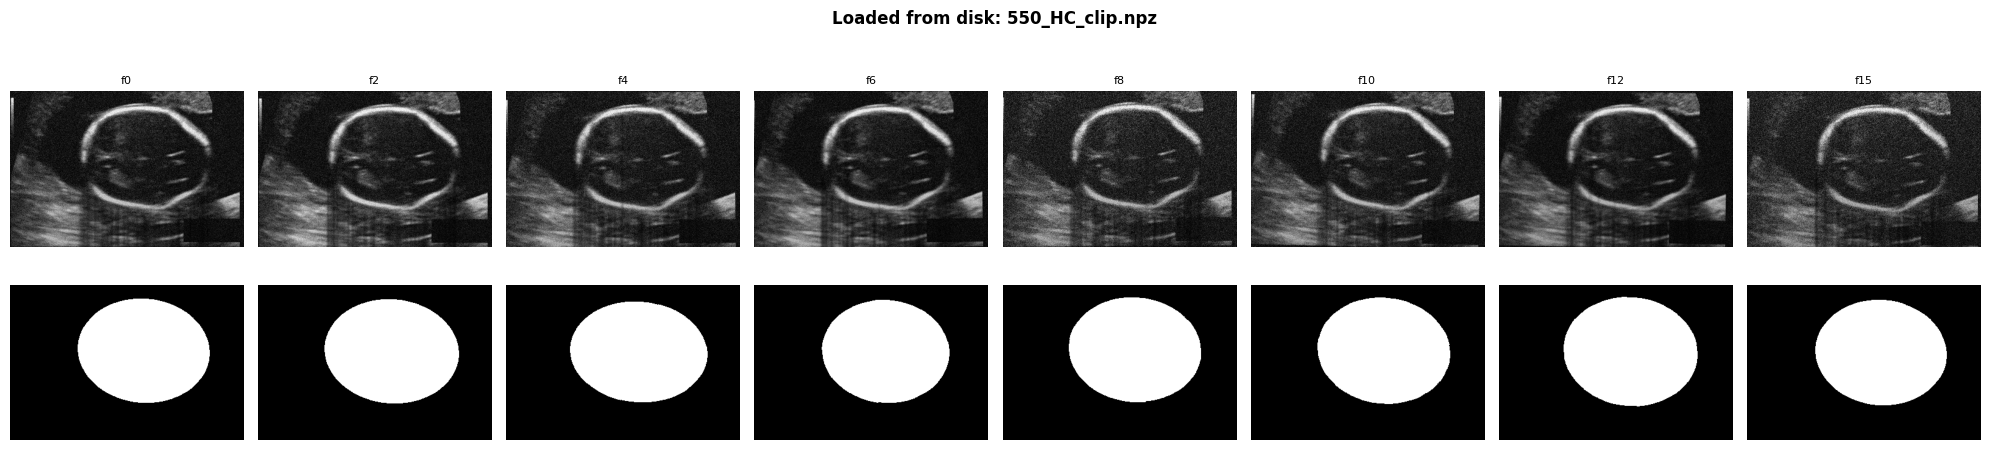

Saved: /content/drive/MyDrive/fetal_head_clinical_ai/results/phase1/sample_clip_portfolio.gif


In [14]:
# Load a random saved clip and verify it loads correctly
sample_npz_paths = list((CINE_DIR / 'train').glob('*.npz'))
random.shuffle(sample_npz_paths)
sample_clip = np.load(str(sample_npz_paths[0]))

loaded_frames = sample_clip['frames']  # [16, H, W] float32
loaded_masks  = sample_clip['masks']   # [16, H, W] uint8

print(f'Loaded clip: {sample_npz_paths[0].name}')
print(f'  Frames: {loaded_frames.shape}  dtype: {loaded_frames.dtype}  range: [{loaded_frames.min():.3f}, {loaded_frames.max():.3f}]')
print(f'  Masks:  {loaded_masks.shape}   dtype: {loaded_masks.dtype}   unique: {np.unique(loaded_masks)}')

visualise_clip(
    loaded_frames, loaded_masks,
    title=f'Loaded from disk: {sample_npz_paths[0].name}',
    save_path=RESULTS_DIR / 'disk_load_verification.png'
)

# Save as GIF for portfolio
save_clip_as_gif(loaded_frames, loaded_masks, RESULTS_DIR / 'sample_clip_portfolio.gif')

In [15]:
# Temporal HC consistency check
# This replaces the always-1.0 reliability score from v1.
# We measure how much HC varies across frames in a clip.
# A non-trivial std confirms the temporal challenge is real.

from skimage.measure import label, regionprops

def estimate_hc_from_mask(mask_bin):
    """Quick HC estimate from binary mask using regionprops."""
    labeled = label(mask_bin)
    if labeled.max() == 0:
        return None
    regions = regionprops(labeled)
    largest = max(regions, key=lambda r: r.area)
    a = largest.major_axis_length / 2
    b = largest.minor_axis_length / 2
    h = ((a - b) / (a + b + 1e-8)) ** 2
    hc_px = np.pi * (a + b) * (1 + (3*h) / (10 + np.sqrt(4 - 3*h + 1e-8)))
    return hc_px

print('Temporal HC variation across 20 sample clips (v1 was always 0.0mm std):')
print(f'{"Clip":<30} {"HC mean (px)":>14} {"HC std (px)":>12} {"Rel score":>10}')
print('-' * 70)

hc_stds = []
for npz_path in sample_npz_paths[:20]:
    clip   = np.load(str(npz_path))
    masks_loaded = clip['masks']
    hc_vals = [estimate_hc_from_mask(m) for m in masks_loaded]
    hc_vals = [v for v in hc_vals if v is not None]
    if len(hc_vals) < 2:
        continue
    hc_arr = np.array(hc_vals)
    std    = hc_arr.std()
    # Reliability score: 1 - normalised std (lower std = more reliable)
    rel    = max(0, 1 - std / (hc_arr.mean() + 1e-8))
    hc_stds.append(std)
    print(f'{npz_path.name:<30} {hc_arr.mean():>14.1f} {std:>12.2f} {rel:>10.4f}')

print(f'\nMean temporal HC std: {np.mean(hc_stds):.2f} px  (v1 was ≈0.0 — reliability was trivially 1.0)')
print('Non-zero std confirms masks vary across frames → temporal reasoning required in Phase 2.')

Temporal HC variation across 20 sample clips (v1 was always 0.0mm std):
Clip                             HC mean (px)  HC std (px)  Rel score
----------------------------------------------------------------------
550_HC_clip.npz                         607.9        13.06     0.9785
162_HC_clip.npz                         574.0        12.35     0.9785
799_HC_clip.npz                         591.9        12.24     0.9793
459_HC_clip.npz                         591.4        15.80     0.9733
182_HC_clip.npz                         320.0         5.13     0.9840
190_HC_clip.npz                         745.3        14.48     0.9806
452_HC_clip.npz                         701.8        12.04     0.9828
740_HC_clip.npz                         641.0         7.89     0.9877
698_HC_clip.npz                         558.3        11.09     0.9801
000_HC_clip.npz                         309.7         6.66     0.9785
413_HC_clip.npz                         723.3        16.19     0.9776
422_HC_clip.npz  

In [16]:
# Final summary
print('=== PHASE 1 SUMMARY ===')
print(f'Cine clips generated: {len(df_cine)}')
print(f'  Train: {len(train_meta)} | Val: {len(val_meta)} | Test: {len(test_meta)}')
print(f'Frames per clip: {N_FRAMES}')
print(f'Frame resolution: {INPUT_H} x {INPUT_W}')
print(f'Generation stage: 4 (full clinical fidelity)')
print(f'Dataset saved to: {CINE_DIR}')
print(f'Metadata CSV: {CINE_DIR}/metadata.csv')
print()
print('v2 improvements over course v1:')
print('  [x] Cross-sectional mask variation (masks no longer perfectly co-transform)')
print('  [x] Ornstein-Uhlenbeck motion (non-periodic, mean-reverting)')
print('  [x] Rician speckle noise (physically correct US noise model)')
print('  [x] Depth-dependent attenuation')
print('  [x] Acoustic shadowing behind skull')
print('  [x] TGC drift between frames')
print('  [x] Non-trivial temporal HC std (vs always-0.0 in v1)')
print()
print('Ready for Phase 2 — 2D U-Net + temporal attention training.')

=== PHASE 1 SUMMARY ===
Cine clips generated: 806
  Train: 564 | Val: 121 | Test: 121
Frames per clip: 16
Frame resolution: 256 x 384
Generation stage: 4 (full clinical fidelity)
Dataset saved to: /content/drive/MyDrive/fetal_head_clinical_ai/cine_dataset
Metadata CSV: /content/drive/MyDrive/fetal_head_clinical_ai/cine_dataset/metadata.csv

v2 improvements over course v1:
  [x] Cross-sectional mask variation (masks no longer perfectly co-transform)
  [x] Ornstein-Uhlenbeck motion (non-periodic, mean-reverting)
  [x] Rician speckle noise (physically correct US noise model)
  [x] Depth-dependent attenuation
  [x] Acoustic shadowing behind skull
  [x] TGC drift between frames
  [x] Non-trivial temporal HC std (vs always-0.0 in v1)

Ready for Phase 2 — 2D U-Net + temporal attention training.
